In [17]:
#25 de junio
#Modificacion del ejemplo de Lorenz
#Filtraré los datos de la matriz de Hankel H (de manera equivalente, X_delay) usando el encoder SVD

In [19]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp
import pysindy as ps

In [20]:
#Modelo real del sistema de Lorenz
def lorenz(t,state,sigma=10, rho=28, beta=8/3):
    x,y,z = state
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

In [21]:
#Genero datos reales de x (que equivale a x1)
dt = 0.01
t_span = (0, 50) #Empiezo en el segundo 0 y acabo en el 50
t_eval = np.arange(t_span[0], t_span[1], dt) #Vector que divide 0 a 50 en intervalos de 0.01 de longitud
x0 = [-8, 7, 27] #Inicializo el problema

sol = solve_ivp(lorenz, t_span, x0, t_eval=t_eval)
X_real = sol.y.T  # Dimensiones: (muestras, 3). Me devolvio el supuesto valor de x,y,z en 0,0.01,0.02,...,50
#print("X_real=\n",X_real)
print(f"Forma de la matriz de soluciones reales X_real: {X_real.shape}")

# Fingimos que solo medimos la primera variable x (==x1) y le añadimos ruido
y_medido = X_real[:, 0] + np.random.normal(0, 0.05, size=len(t_eval))

Forma de la matriz de soluciones reales X_real: (5000, 3)


In [22]:
#Creamos el espacio de retardos (embedding)
#El teorema de Taken dice que n>2m y en este caso m=3, por lo que n debería ser 7
#Sin embargo, como conozco el modelo de Lorenz (se supone que no), n=3 bastará porque corresponde a las 3 variables del sistema
#Sin embargo, voy a usar n mayor para demostrar la reduccion de dimensionalidad gracias al encoder
n_delays = 15   # Dimensión de incrustación (creamos z1, z2, ...,z15)
tau = 5       # retraso temporal (delay)

#X_delay es H matriz de Hankel del articulo pero traspuesta
r=len(y_medido) - (n_delays - 1) * tau
X_delay = np.zeros((r, n_delays)) 
for i in range(n_delays):
    X_delay[:, i] = y_medido[i * tau : r + i * tau]  #En la columna i, meto los datos de y desde i*tau hasta r+i*tau

print(f"Forma X_delay:{X_delay.shape}")

Forma X_delay:(4930, 15)


In [23]:
#Aplicamos SVD a la matriz de Hankel (X_delay)
# Paso a X_delay.T porque el SVD estándar del paper organiza las muestras por columnas
U, S, Vt = np.linalg.svd(X_delay.T, full_matrices=False)
V = Vt.T # Estas son las "coordenadas v" del artículo de HAVOK

# Reducción de dimensionalidad 
# Elegimos quedarnos solo con las r componentes principales con más energía.
# Escojo r = 7 
r_trunc = 7 

# Filtramos la matriz quedándonos solo con el subespacio de baja dimensión
X_reducido = V[:, :r_trunc] 


In [24]:
#APLICACION DE KOOPMAN. Lo que voy a hacer es TERRIBLE computacionalmente 
#Separamos los datos en Matrices de Presente y Futuro 
Z_pres = X_delay[:-1, :]  # Todas las filas menos la ultima 
Z_fut  = X_delay[1:, :]   # Todas lass filas menos la primera

# Calculamos de forma directa la Matriz de Transición Lineal de Koopman 
# Buscamos la matriz K tal que: Z_fut ≈ Z_pres @ K.T (por mínimos cuadrados)
#Es decir, K transforma la fila 0 en la fila 1, la fila 1 en la fila 2...
K_operador = np.linalg.pinv(Z_pres) @ Z_fut #Como no puedo calcular la inversa de Z_pres (no es cuadrada), pinv calcula una aproximacion por minimos cuadrados
#NO USÉ AUTOENCODER. Lo hice directo en un paso. Funciona pero de manera poco precisa

#Extraemos las Koopman Eigenfunctions usando la diagonalización de la matriz K
lambdas, V_koopman = np.linalg.eig(K_operador)

# Proyectamos la matriz de Hankel al nuevo espacio linealizado
# Al multiplicar por los autovectores, cambiamos a las coordenadas de Koopman
Z_linealizado = X_delay @ V_koopman

print("--- CONTROL DE COMPONENTES DE KOOPMAN ---")
print(f"Dimensión de la Matriz del Operador K: {K_operador.shape}")
print(f"Dimensión de los datos en el espacio lineal de Koopman (Z): {Z_linealizado.shape}")

--- CONTROL DE COMPONENTES DE KOOPMAN ---
Dimensión de la Matriz del Operador K: (15, 15)
Dimensión de los datos en el espacio lineal de Koopman (Z): (4930, 15)


In [25]:
#PREDICCIÓN DEL FUTURO USANDO EL OPERADOR DE KOOPMAN
# Vamos a intentar predecir los próximos 500 pasos en el tiempo partiendo 
# únicamente de la condición inicial del espacio de retardos, aplicando solo: 
# Z_futuro = Z_presente @ K_operador

pasos_prediccion = 500
X_predicho = np.zeros((pasos_prediccion, n_delays))

# Inicializamos 
X_predicho[0, :] = X_delay[0, :]

for t in range(1, pasos_prediccion):
    X_predicho[t, :] = X_predicho[t-1, :] @ K_operador

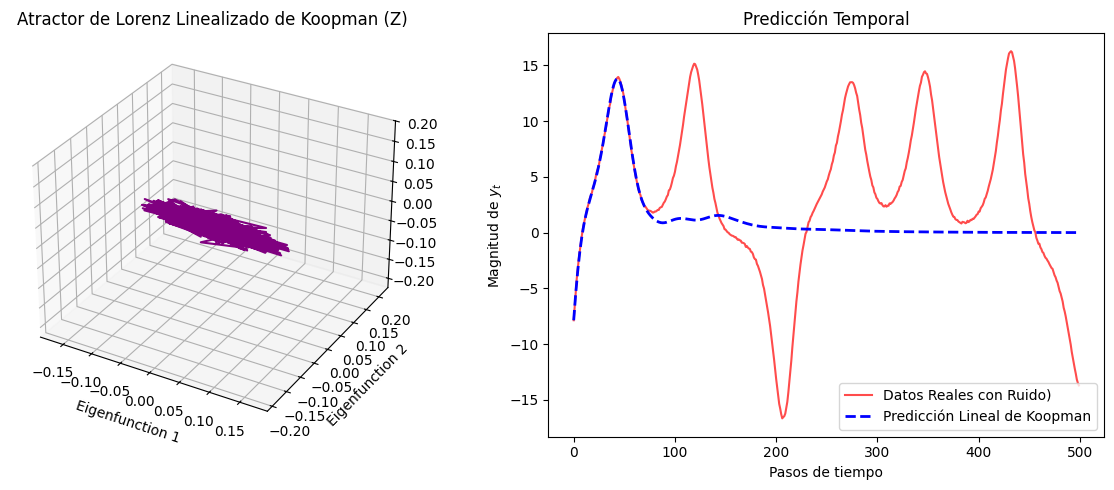

In [26]:
#Graficos
fig = plt.figure(figsize=(12, 5))

# Subplot 1: El Atractor "Linealizado" (ns si puedo decir esto)
ax1 = fig.add_subplot(121, projection='3d')
# Nos quedamos con la parte real de Z porque los autovectores pueden ser complejos
ax1.plot(np.real(Z_linealizado[:, 0]), np.real(Z_linealizado[:, 1]), np.real(Z_linealizado[:, 2]), color='purple')
ax1.set_title("Atractor de Lorenz Linealizado de Koopman (Z)")
ax1.set_xlabel("Eigenfunction 1")
ax1.set_ylabel("Eigenfunction 2")
#ALGO FALLA. Ns si es porque el operador de Koopman es infinito o algo mas
#No es que falle: miro el sistema analizando unas mediciones de las verdaderas variables (sen(x),y^5,...)
#por eso no se muestra la mariposa de siempre

# Subplot 2: Evaluación de la Predicción Lineal vs Datos Reales (en la primera componente)
ax2 = fig.add_subplot(122)
ax2.plot(X_delay[0:pasos_prediccion, 0], 'r-', label='Datos Reales con Ruido)', alpha=0.7)
ax2.plot(X_predicho[:, 0], 'b--', label='Predicción Lineal de Koopman', linewidth=2)
ax2.set_title("Predicción Temporal")
ax2.set_xlabel("Pasos de tiempo")
ax2.set_ylabel("Magnitud de $y_t$")
ax2.legend()

plt.tight_layout()
plt.show()